# Examen 

In [49]:
# Your imports HERE !!!!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 01 - 1 pt
- Dado un array de elementos, escribir una función, que reciba dicho array como parámetro de entrada y devuelva el elemento repetido. Usando plain Python, sin ninguna librería.

In [77]:
array_src = [4, 8, 0, 3, 6, 2, 1, 5, 3, 9, 7]
expected_rep_element = 3
rep_element = repeated_element(array_src) # This calls your function repeated_element
assert(expected_rep_element == rep_element)  # This will fail if the element is not found correctly

# Mostrar resultados
print(f"Elemento encontrado: {rep_element}")
print(f"Elemento esperado: {expected_rep_element}")

Elemento encontrado: 3
Elemento esperado: 3


In [75]:
# Your solution HERE !!!!
def repeated_element(arr):
    seen = set()
    for element in arr:
        if element in seen:
            return element
        seen.add(element)
    return None

## 02 - 1pt
- Genera una matriz con valores aleatorios de 0 a 100 de dimensiones 16x16
- Calcula los siguentes estadísticos en la matriz anterior, por fila (el resultado de cada uno debe ser un array de dimensiones 1x16)
  - Suma de los elementos de cada fila
  - Media de los elementos de cada fila
  - Valores mínimos de cada fila
  - Valores máximos de cada fila

In [48]:
# Your solution HERE !!!!
# Generamos la matriz 16x16 con valores aleatorios 0-100
matrix = np.random.randint(0, 101, size=(16, 16))

# Calcular estadísticos por fila
row_sums = matrix.sum(axis=1)
row_means = matrix.mean(axis=1)
row_mins = matrix.min(axis=1)
row_maxs = matrix.max(axis=1)

print("Sumas por fila:", row_sums)
print("Medias por fila:", row_means)
print("Mínimos por fila:", row_mins)
print("Máximos por fila:", row_maxs)

Sumas por fila: [ 753  806 1013  848  807  834  582  881  730  809  729  894  923  714
  992  715]
Medias por fila: [47.0625 50.375  63.3125 53.     50.4375 52.125  36.375  55.0625 45.625
 50.5625 45.5625 55.875  57.6875 44.625  62.     44.6875]
Mínimos por fila: [ 7  6 17 12  2  3  0 11  6  6  5 15  0  0  1  6]
Máximos por fila: [ 88  97  97  95  95  94  99  93  88  87  94  99  97  98 100  95]


## 03 - 1pt

- Generar un dataframe de 3x4 dimensiones con valores númericos aleatorios [0,10]
- Darle un índice semántico alfanumérico
- Aplicarle una función lambda que obtenga la diferencia entre el máximo y mínimo de cada fila

In [52]:
# Your solution HERE !!!!
# Creamos DataFrame 3x4 con valores aleatorios de 0-10
df = pd.DataFrame(np.random.randint(0, 11, size=(3, 4)))

# Damos índice alfanumérico
df.index = ['A1', 'B2', 'C3']

# Aplicamos lambda para diferencia entre max y min por fila
df['max_min_diff'] = df.apply(lambda row: row.max() - row.min(), axis=1)

print(df)

     0  1  2  3  max_min_diff
A1   4  7  3  7             4
B2   0  0  5  1             5
C3  10  9  9  6             4


## 04 - 1pt
- Crear un array de NumPy de dimensiones 8x5, con números enteros aleatorios en el rango [-100, 100]
- Ejecutar en este orden

  1. Reemplazar los valores de todos aquellos números múltiplos de 5 por 100
  2. Reemplazar los valores de todos aquellos números múltiplos de 3 por Nan
   
  2. Averiguar cuantos elementos tienen Nan por fila
  3. Reemplazar los valores de Nan por 0

In [58]:
# Your solution HERE !!!!
# Creamos array 8x5 con enteros aleatorios -100 a 100
arr = np.random.randint(-100, 101, size=(8, 5))

# Convertimos el array a tipo float para poder usar NaN
arr = arr.astype(float)

# 1. Reemplazamos múltiplos de 5 por 100
arr[arr % 5 == 0] = 100

# 2. Reemplazamos múltiplos de 3 por NaN
arr[arr % 3 == 0] = np.nan

# 3. Contamos los NaNs por fila
nan_counts = np.isnan(arr).sum(axis=1)

# 4. Reemplazamos NaNs por 0
arr = np.nan_to_num(arr, nan=0)

print("Array final:\n", arr)
print("Conteo de NaNs por fila:", nan_counts)

Array final:
 [[  0. -94. -79. -19.   0.]
 [-58. -19.  79.  31.   0.]
 [-28.  71.  46.   0.   0.]
 [-31. 100. 100.  29.   0.]
 [100.   0.  56. 100.   0.]
 [100.  17. -13.   0.   0.]
 [  0. -16. 100. -64.  34.]
 [ 29.  77.   0.  83.   0.]]
Conteo de NaNs por fila: [2 1 2 1 2 2 1 2]


## 05 - 1pt
- Crear una función que reciba una lista de strings y devuelva una serie de pandas, y convierta el primer y último carácter de la palabra de cada elemento de la serie a mayúsculas

In [78]:
languages = ['python', 'php', 'java', 'javascript', 'c++', 'sql']
expected_output = pd.Series(['PythoN', 'PhP', 'JavA', 'JavascripT', 'C++', 'SqL'])
output = first_last_uppercase(languages)  # This calls your function first_last_uppercase
assert(expected_output.equals(output))  # This will fail if the two lists are different

print("Resultado obtenido:")
print(output)
print("\nResultado esperado:")
print(expected_output)

Resultado obtenido:
0        PythoN
1           PhP
2          JavA
3    JavascripT
4           C++
5           SqL
dtype: object

Resultado esperado:
0        PythoN
1           PhP
2          JavA
3    JavascripT
4           C++
5           SqL
dtype: object


In [63]:
# Your solution HERE !!!!
def first_last_uppercase(lst):
    def process_word(word):
        if len(word) == 0:
            return word
        elif len(word) == 1:
            return word[0].upper()
        else:
            return word[0].upper() + word[1:-1] + word[-1].upper()
    
    return pd.Series([process_word(word) for word in lst])

## 06 - 1pt
- La serie de Fibonacci es una sucesión de números, en la cual cada número es la suma de los dos anteriores. Los dos primeros son siempre 0 y 1.
  - $F_0 = 0$
  - $F_1 = 1$
  - $F_n = F_{n-1} + F_{n-2}$
- Crear un generador infinito de números de Fibonacci.

In [89]:
fibo = [0,1,1,2,3,5,8,13,21,34,55,89,144,233,377,610,987,1597]
g = fibonacci_generator()  # This calls tour function fibonacci_generator
expected_output = [next(g) for n in range(len(fibo))]
assert(fibo == expected_output)  # This will fail if the output is not as expected

In [88]:
# Your solution HERE !!!!
def fibonacci_generator():
    a, b = 0, 1
    yield a
    yield b
    while True:
        a, b = b, a + b
        yield b

## 07 - 4pt
- Crear una lista de meses de Enero a Diciembre (eje X)
- Generar datos aleatorios para el eje Y, hacerlo 3 veces distintas (Y0, Y1 e Y2)
- Representar las 3 secuencias de datos aleatorios en una sola figura usando matplotlib
- Añadir una leyenda para poder identificar cada secuencia
- Nombrar las 3 secuencias de la siguiente manera ("Facebook", "Twitter", "Instagram")
- Añadir un título y nombres a los dos ejes
- Añadir una anotación (texto y flecha) a uno de los gráficos

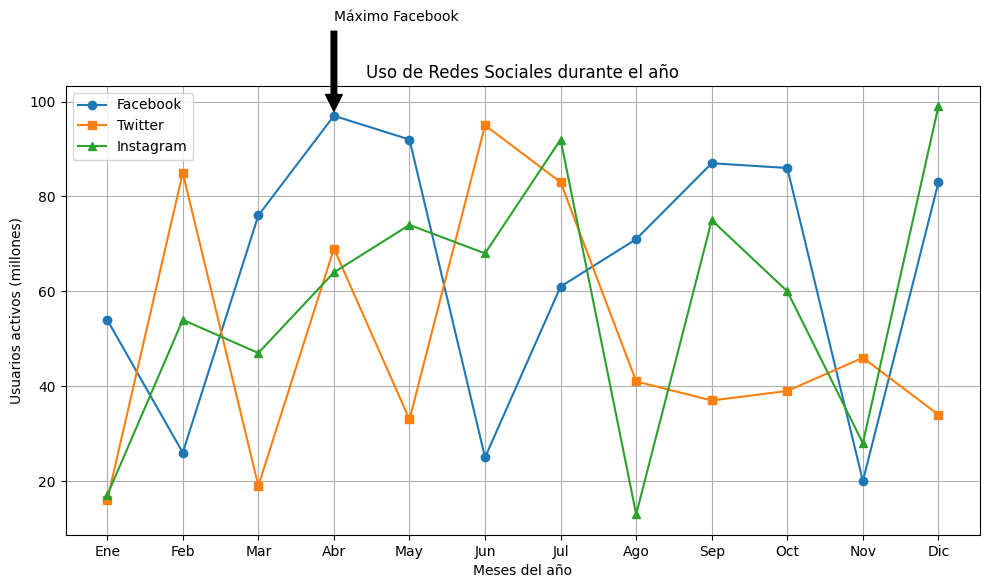

In [73]:
# Your solution HERE !!!!
# Creamos la lista de los meses
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Generamos 3 conjuntos de datos aleatorios
y0 = np.random.randint(0, 100, size=12)
y1 = np.random.randint(0, 100, size=12)
y2 = np.random.randint(0, 100, size=12)

# Creamos figura usando matplotlib
plt.figure(figsize=(10, 6))

# Graficamos las 3 series
plt.plot(meses, y0, label='Facebook', marker='o')
plt.plot(meses, y1, label='Twitter', marker='s')
plt.plot(meses, y2, label='Instagram', marker='^')

# Añadimos los elementos gráficos
plt.title('Uso de Redes Sociales durante el año')
plt.xlabel('Meses del año')
plt.ylabel('Usuarios activos (millones)')
plt.legend()

# Añadimos anotaciones (ejemplo para el punto máximo de Facebook)
max_idx = np.argmax(y0)
plt.annotate('Máximo Facebook', 
             xy=(meses[max_idx], y0[max_idx]), 
             xytext=(meses[max_idx], y0[max_idx] + 20),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.grid(True)
plt.tight_layout()
plt.show()
